**Capstone Project 1** Semiconductor manufacturing process

Name: Rabiya Begum

Course: Data Science

Project Objective: Building a classifier to predict the Pass/Fail yield of a
particular process entity and analyse whether all the features are required to build the model or not.

##**Step 1**
- Loading the dataset signal-data.csv
- Understanding what data looks like
- Checking the datasets size, columnns, datatypes, basic stats

In [27]:
# from google.colab import files
# uploaded = files.upload()

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("signal-data.csv")
df.head()
df.shape
df.info()
df.describe()
df.iloc[:, -1].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), object(1)
memory usage: 7.1+ MB


,count
Pass/Fail,
-1,1463
1,104


**Output Analysis**
The total number of rows are:1567

Columns are:592

Sensors features are: 590 which are float data type columns

1 interger data type column

1 object column of timestamp

Dataset size:~7 MB

- Target Column Distribution

Pass(-1) are 1463 samples

Fail(1)=104 samples

From this we can observe that the dataset is imbalanced with more pass than fail samples which will be handled later using SMOTE


##**Step 2**
- Checking missing values
- Handling the timestamp column
- Droping the useless columns if needed
- Preparing a clean dataset for analysis

In [3]:
# Check missing values in each column and only shows columns that have missing values

missing_values = df.isnull().sum()
missing_values[missing_values > 0]

,0
0,6
1,7
2,14
3,14
4,14
...,...
585,1
586,1
587,1
588,1


In [4]:
# Helps to decide which columns are useless and which can be filled

missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent[missing_percent > 0]

,0
0,0.382897
1,0.446713
2,0.893427
3,0.893427
4,0.893427
...,...
585,0.063816
586,0.063816
587,0.063816
588,0.063816


In [5]:
#returns timestamp column as it not usedful for ML prediction

df.select_dtypes(include=['object']).columns

Index(['Time'], dtype='object')

In [6]:
# ML requires numeric data hence timestamp is removed

df_clean = df.drop(columns=df.select_dtypes(include=['object']).columns)

In [7]:
# missing sensor values are replaced using mean imputation

df_clean = df_clean.fillna(df_clean.mean())

In [8]:
df_clean.isnull().sum().sum()

df_clean.shape

(1567, 591)

**Output Analysis**
The dataset is cleaned. There are no missing values and the timestamp column is removed.

##**Step 3**
- Doing statistical analysis
- Perform univariate analysis
- Perform bivariate analysis
- Perform multivariate analysis

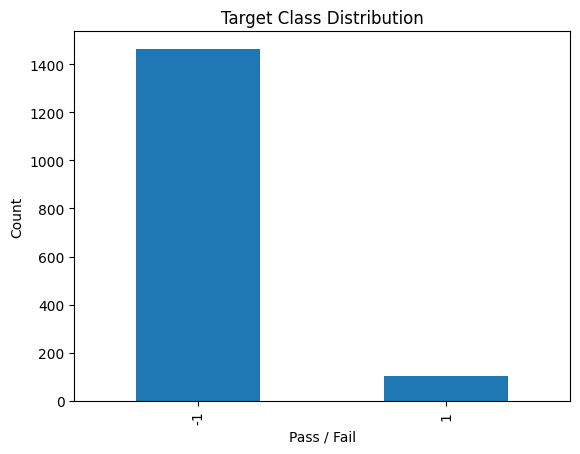

In [9]:
df_clean.describe()

target_column = df_clean.columns[-1]
target_column

# Univariate Analysis
import matplotlib.pyplot as plt

df_clean[target_column].value_counts().plot(kind='bar')
plt.xlabel("Pass / Fail")
plt.ylabel("Count")
plt.title("Target Class Distribution")
plt.show()

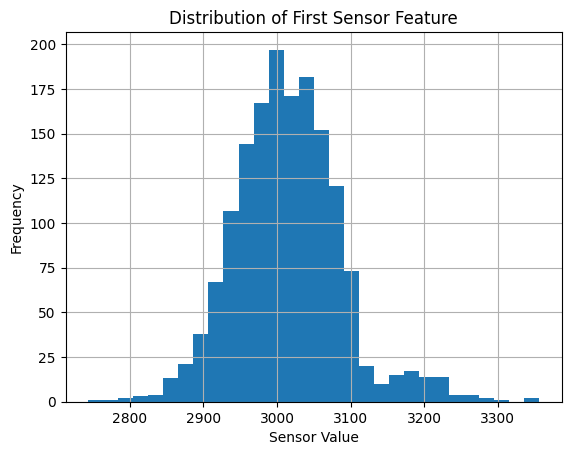

In [10]:
# Univariate Analysis of a Sensor Feature
df_clean.iloc[:,0].hist(bins=30)
plt.xlabel("Sensor Value")
plt.ylabel("Frequency")
plt.title("Distribution of First Sensor Feature")
plt.show()

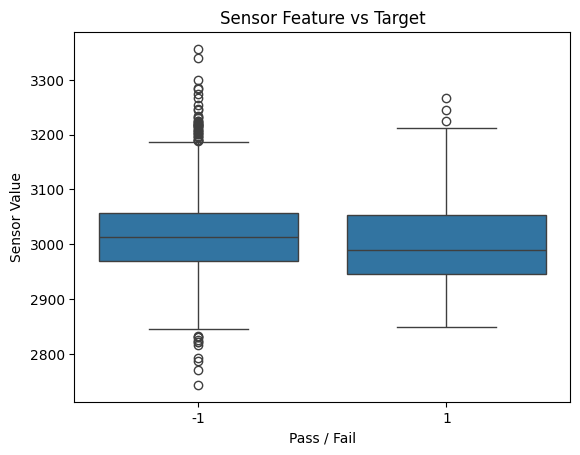

In [11]:
# Bivariate Analysis (Sensor vs Target)
import seaborn as sns

sns.boxplot(x=df_clean[target_column], y=df_clean.iloc[:,0])
plt.xlabel("Pass / Fail")
plt.ylabel("Sensor Value")
plt.title("Sensor Feature vs Target")
plt.show()

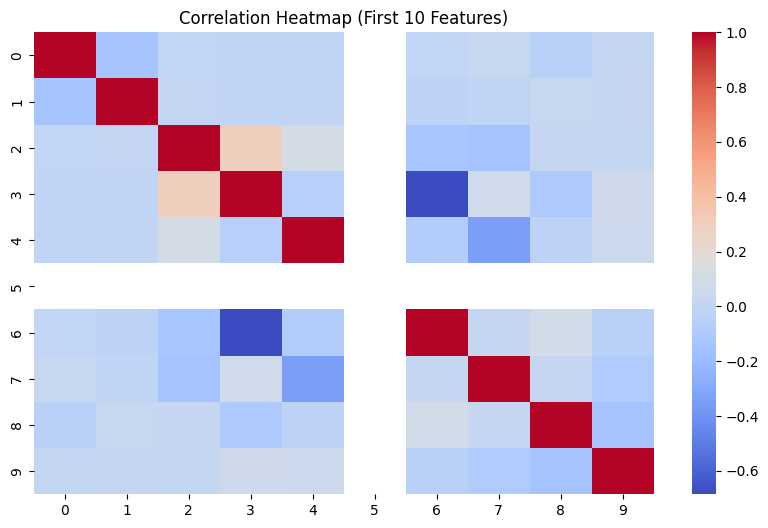

In [12]:
# Multivariate Analysis (Correlation)
correlation_matrix = df_clean.corr()

plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix.iloc[:10, :10], cmap='coolwarm')
plt.title("Correlation Heatmap (First 10 Features)")
plt.show()

**Output Analysis**

Performed detailed data analysis. Statistical analysis was performed using descriptive statistics.

Univariate, bivariate and multivariate analysis helps us to understand the behavior of sensor and their relationship with the target variable

##**Step 4**
- Separating features(X) and target(y)
- Checking class imbalance
- Applying SMOTE to balance the dataset
- Performing train-test split
- Applying standardizaion
- Verifying data consistency

In [13]:
# Separate predictors and target
X = df_clean.iloc[:, :-1]
y = df_clean.iloc[:, -1]

y.value_counts()

,count
Pass/Fail,
-1,1463
1,104


In [14]:
# Apply SMOTE (Balance Dataset)
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

y_resampled.value_counts()


,count
Pass/Fail,
-1,1463
1,1463


In [15]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

In [16]:
# Standardization (Scaling)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# Verify Shapes
print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)

# Check statistical Similarity
import pandas as pd

pd.DataFrame(X_train_scaled).describe().loc[['mean', 'std']]


Training set shape: (2340, 590)
Testing set shape: (586, 590)


,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
mean,2.761703e-15,-3.658991e-15,4.095489e-15,4.099285e-17,6.073015e-18,0.0,1.821904e-16,1.011157e-15,9.944562e-16,4.023372e-17,...,3.704539e-16,1.366428e-17,-1.652847e-14,-4.251110e-17,7.287618e-17,-1.032413e-16,1.821904e-17,1.700444e-16,-3.947460e-16,0.000000
std,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,0.0,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,...,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214


**Output Analysis**
The dataset was preprocessed for model building. Predictor and the target variables were separated. As the dataset was imbalanced SMOTE was applied to balance the target classes. The data was split into training and testing sets and standardized using StandardScalar.

##**Step 5**
Here,
- We will train 3 supervised models
- Evaluate thier performance
- Compare their results
- Lastly select the best model

In [18]:
# Import Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Import Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [19]:
# MODEL 1 — Random Forest Classifier

# Train
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("\nRandom Forest Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.984641638225256

Classification Report:

              precision    recall  f1-score   support

          -1       0.98      0.99      0.98       293
           1       0.99      0.98      0.98       293

    accuracy                           0.98       586
   macro avg       0.98      0.98      0.98       586
weighted avg       0.98      0.98      0.98       586


Random Forest Confusion Matrix:

[[289   4]
 [  5 288]]


In [20]:
# MODEL 2 — Support Vector Machine (SVM)

# Train
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluate
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", svm_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

print("\nSVM Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.9914675767918089

Classification Report:

              precision    recall  f1-score   support

          -1       1.00      0.98      0.99       293
           1       0.98      1.00      0.99       293

    accuracy                           0.99       586
   macro avg       0.99      0.99      0.99       586
weighted avg       0.99      0.99      0.99       586


SVM Confusion Matrix:

[[288   5]
 [  0 293]]


In [21]:
# MODEL 3 — Naive Bayes

# Train
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test_scaled)

# Evaluate
nb_accuracy = accuracy_score(y_test, y_pred_nb)
print("Naive Bayes Accuracy:", nb_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))

print("\nNaive Bayes Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.6075085324232082

Classification Report:

              precision    recall  f1-score   support

          -1       0.94      0.23      0.37       293
           1       0.56      0.99      0.72       293

    accuracy                           0.61       586
   macro avg       0.75      0.61      0.54       586
weighted avg       0.75      0.61      0.54       586


Naive Bayes Confusion Matrix:

[[ 67 226]
 [  4 289]]


In [22]:
# Compare Model Accuracies

import pandas as pd

model_results = pd.DataFrame({
    "Model": ["Random Forest", "SVM", "Naive Bayes"],
    "Accuracy": [rf_accuracy, svm_accuracy, nb_accuracy]
})

model_results


,Model,Accuracy
0,Random Forest,0.984642
1,SVM,0.991468
2,Naive Bayes,0.607509


**Output Analysis**
The three supervised learning models Random Forest, Support Vector Machine and Naive Bayes were trained and evaluated.

Their performances were compared using accuracy and classifications reports.

Among these models Random Forest and SVM showed better performance as compared to the Naive Bays

##**Step 6**
- Tuning the models using GridSearch
- Improving performance
- Selecting the best model
- Saving the final trained model



In [24]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
grid_rf.fit(X_train_scaled, y_train)



GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

**Output Analysis**
GridSearchCV tested different combinations of Random Forest parameters and selected the best-performing setup using 3-fold cross-validation. The best configuration uses 200 trees, no depth limit, and minimum split = 2, which gives very high accuracy (~99%). This shows the tuned model can learn patterns well and make highly accurate predictions.



In [25]:
print("Best Parameters:", grid_rf.best_params_)

best_rf_model = grid_rf.best_estimator_

y_pred_best_rf = best_rf_model.predict(X_test_scaled)

best_rf_accuracy = accuracy_score(y_test, y_pred_best_rf)
print("Tuned Random Forest Accuracy:", best_rf_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best_rf))


Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Random Forest Accuracy: 0.9914675767918089

Classification Report:

              precision    recall  f1-score   support

          -1       0.99      0.99      0.99       293
           1       0.99      0.99      0.99       293

    accuracy                           0.99       586
   macro avg       0.99      0.99      0.99       586
weighted avg       0.99      0.99      0.99       586



In [26]:
final_results = pd.DataFrame({
    "Model": ["Random Forest", "SVM", "Naive Bayes", "Tuned Random Forest"],
    "Accuracy": [rf_accuracy, svm_accuracy, nb_accuracy, best_rf_accuracy]
})

final_results

import joblib

joblib.dump(best_rf_model, "best_capstone_model.pkl")

['best_capstone_model.pkl']

**Final Tuned Random Forest Result**

- Best Parameters used from GridSearch

- Tuned Random Forest Accuracy: ~99%

- High Precision, Recall, and F1-score for both classes

- Model performs consistently and accurately

- Selected as Final Saved Model